### Installing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading csv file


In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Handling missing values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
data.isnull().mean()*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [7]:
cols = [var for var in data.columns if data[var].isnull().mean() < 0.03 and data[var].isnull().mean() > 0]
cols

['total_bedrooms']

In [8]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())


In [9]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
x=data.drop(['median_house_value'], axis=1)
y=data['median_house_value']

In [12]:
y


0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [14]:
train_data = x_train.join(y_train)

In [15]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
8864,-118.39,34.06,43.0,1879.0,397.0,873.0,382.0,3.8158,<1H OCEAN,500001.0
12564,-121.43,38.54,44.0,1879.0,359.0,791.0,345.0,3.1500,INLAND,101500.0
13858,-117.27,34.49,7.0,2344.0,351.0,846.0,314.0,4.7361,INLAND,174500.0
5286,-118.46,34.05,21.0,3639.0,1002.0,1489.0,983.0,4.6197,<1H OCEAN,387500.0
15322,-117.35,33.20,32.0,1251.0,220.0,700.0,232.0,3.9875,NEAR OCEAN,142900.0
...,...,...,...,...,...,...,...,...,...,...
18544,-122.03,36.97,52.0,403.0,72.0,200.0,73.0,1.6923,NEAR OCEAN,262500.0
12775,-121.41,38.64,41.0,1578.0,317.0,897.0,333.0,2.3214,INLAND,66800.0
6734,-118.10,34.12,49.0,3783.0,579.0,1601.0,539.0,6.3013,<1H OCEAN,500001.0
20415,-118.84,34.17,16.0,3449.0,820.0,1877.0,816.0,3.2176,<1H OCEAN,187500.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

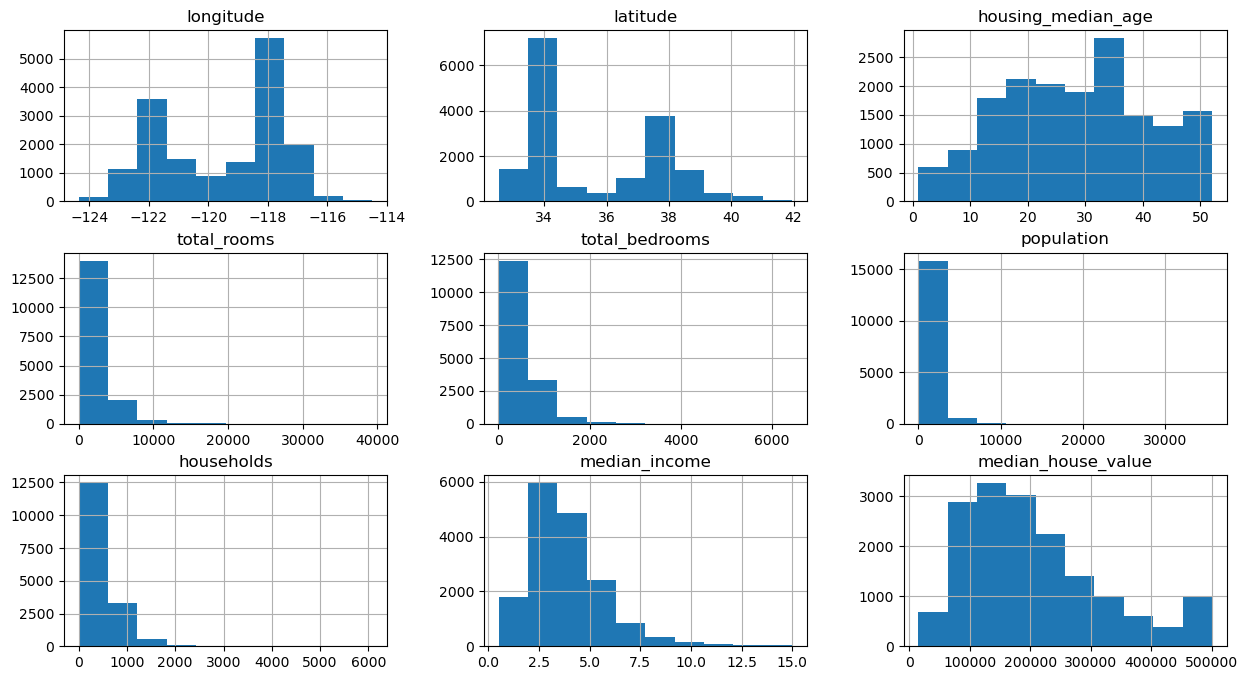

In [16]:
train_data.hist(figsize=(15, 8))

In [17]:
print(data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


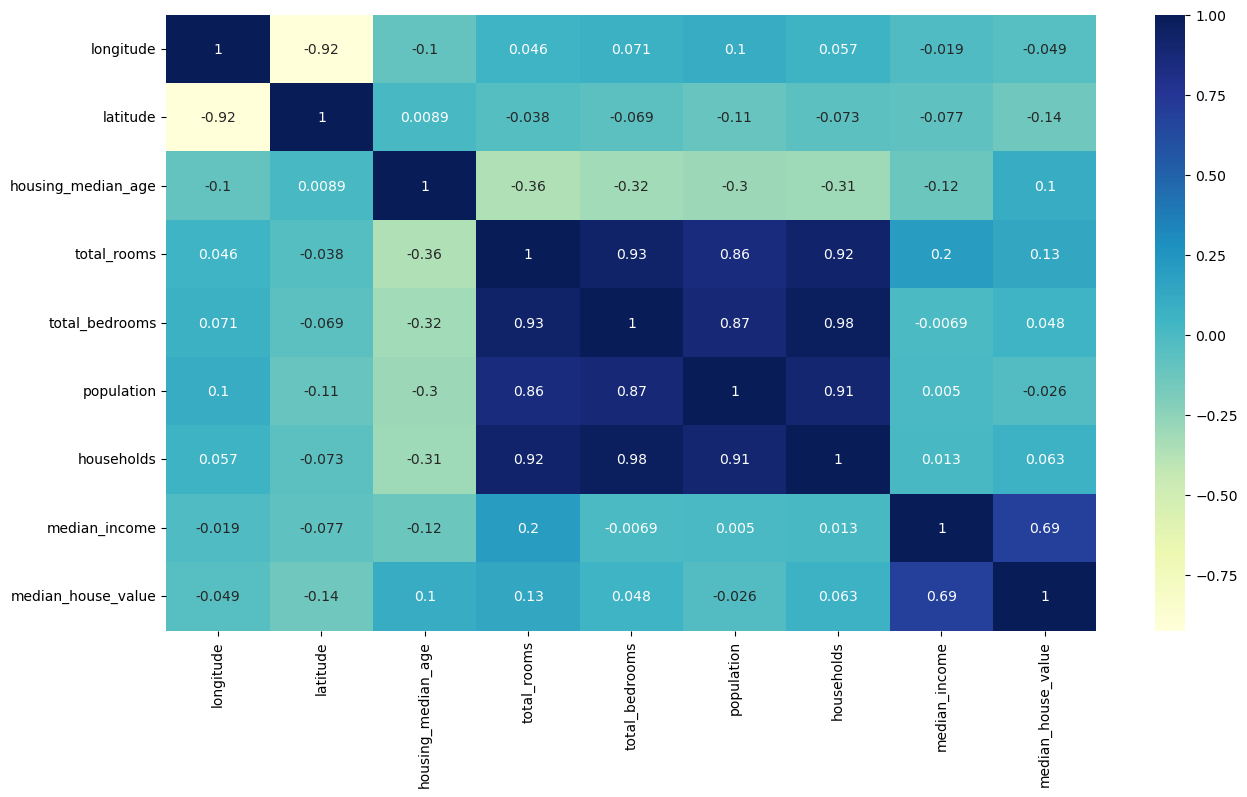

In [18]:
plt.figure(figsize=(15, 8))
numeric_data = train_data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap="YlGnBu")
plt.show()


### Key Observations:
total_rooms and total_bedrooms → 0.93 correlation (Very High).

households and total_bedrooms → 0.98 correlation (Almost perfect correlation).

median_income and median_house_value → 0.69 (Strong positive correlation).

latitude and longitude → -0.93 (Strong negative correlation).

In [19]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

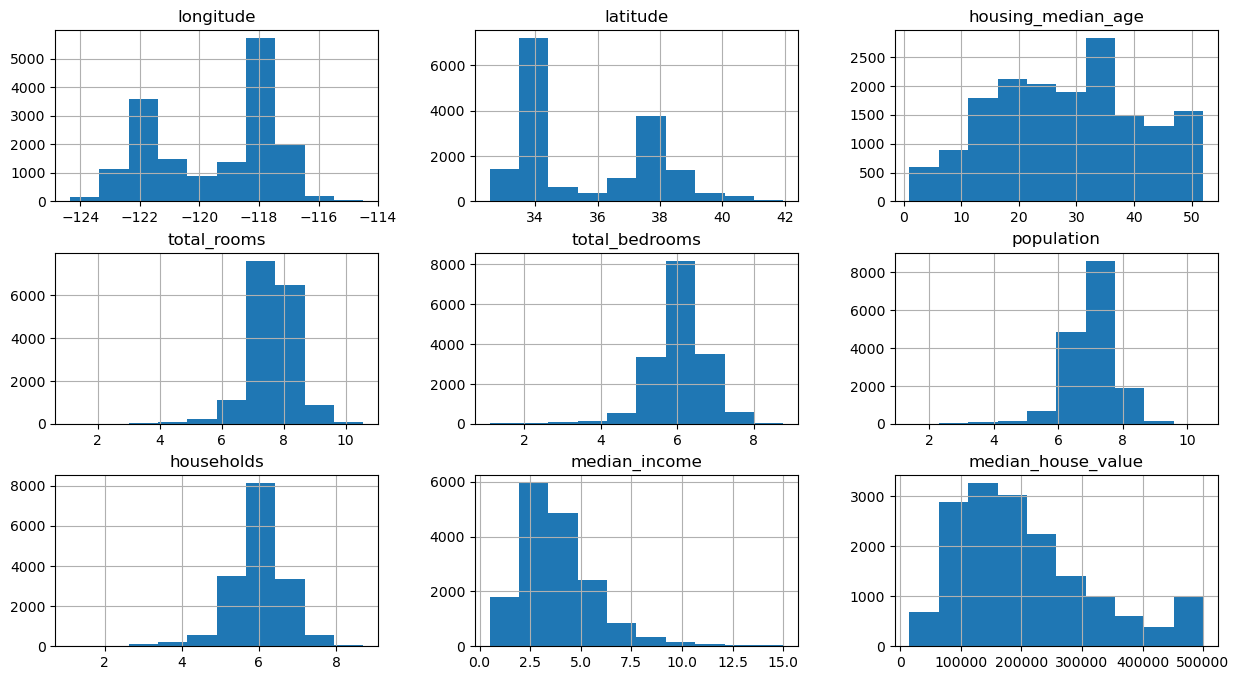

In [20]:
train_data.hist(figsize=(15, 8))

In [21]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7297
INLAND        5236
NEAR OCEAN    2154
NEAR BAY      1820
ISLAND           5
Name: count, dtype: int64

In [22]:
pd.get_dummies(train_data.ocean_proximity)


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8864,True,False,False,False,False
12564,False,True,False,False,False
13858,False,True,False,False,False
5286,True,False,False,False,False
15322,False,False,False,False,True
...,...,...,...,...,...
18544,False,False,False,False,True
12775,False,True,False,False,False
6734,True,False,False,False,False
20415,True,False,False,False,False


In [23]:
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'], drop_first=True)).drop(['ocean_proximity'], axis=1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
8864,-118.39,34.06,43.0,7.539027,5.986452,6.773080,5.948035,3.8158,500001.0,False,False,False,False
12564,-121.43,38.54,44.0,7.539027,5.886104,6.674561,5.846439,3.1500,101500.0,True,False,False,False
13858,-117.27,34.49,7.0,7.760041,5.863631,6.741701,5.752573,4.7361,174500.0,True,False,False,False
5286,-118.46,34.05,21.0,8.199739,6.910751,7.306531,6.891626,4.6197,387500.0,False,False,False,False
15322,-117.35,33.20,32.0,7.132498,5.398163,6.552508,5.451038,3.9875,142900.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18544,-122.03,36.97,52.0,6.001415,4.290459,5.303305,4.304065,1.6923,262500.0,False,False,False,True
12775,-121.41,38.64,41.0,7.364547,5.762051,6.800170,5.811141,2.3214,66800.0,True,False,False,False
6734,-118.10,34.12,49.0,8.238537,6.363028,7.379008,6.291569,6.3013,500001.0,False,False,False,False
20415,-118.84,34.17,16.0,8.146130,6.710523,7.537963,6.705639,3.2176,187500.0,False,False,False,False


<Axes: >

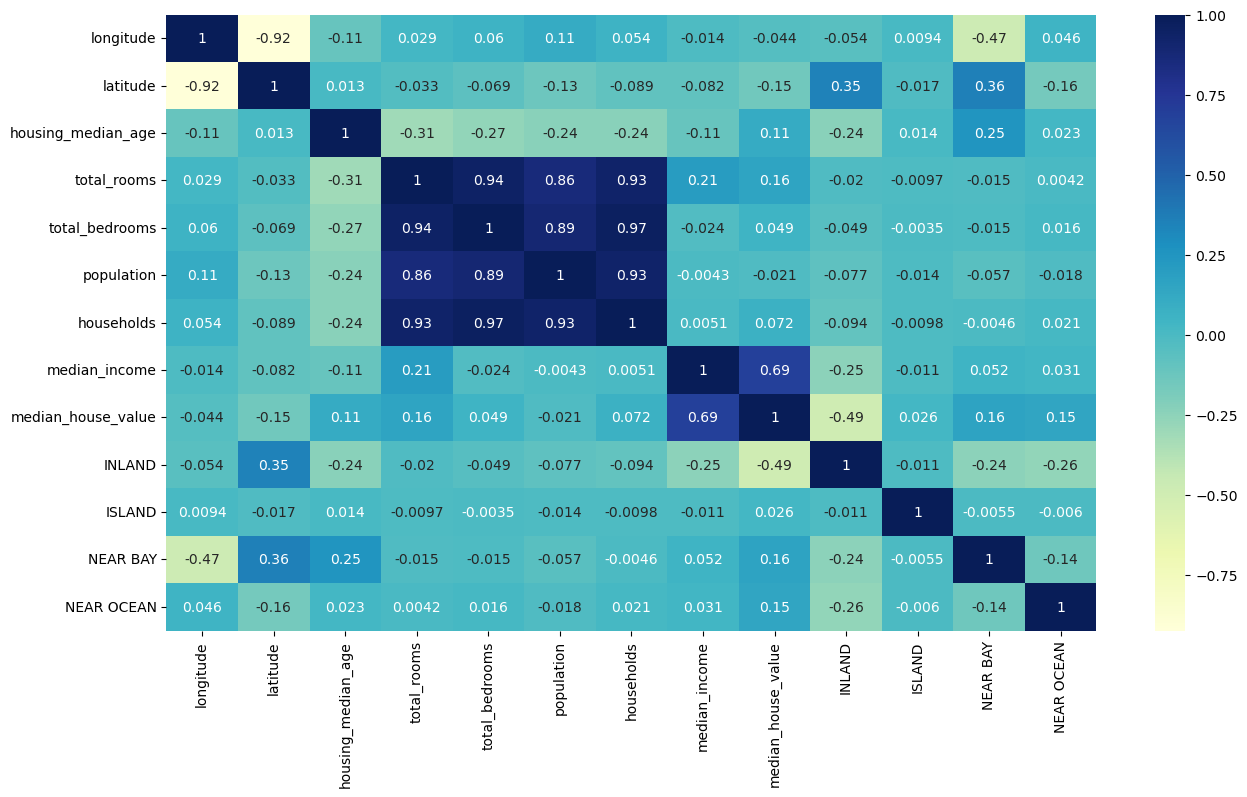

In [178]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

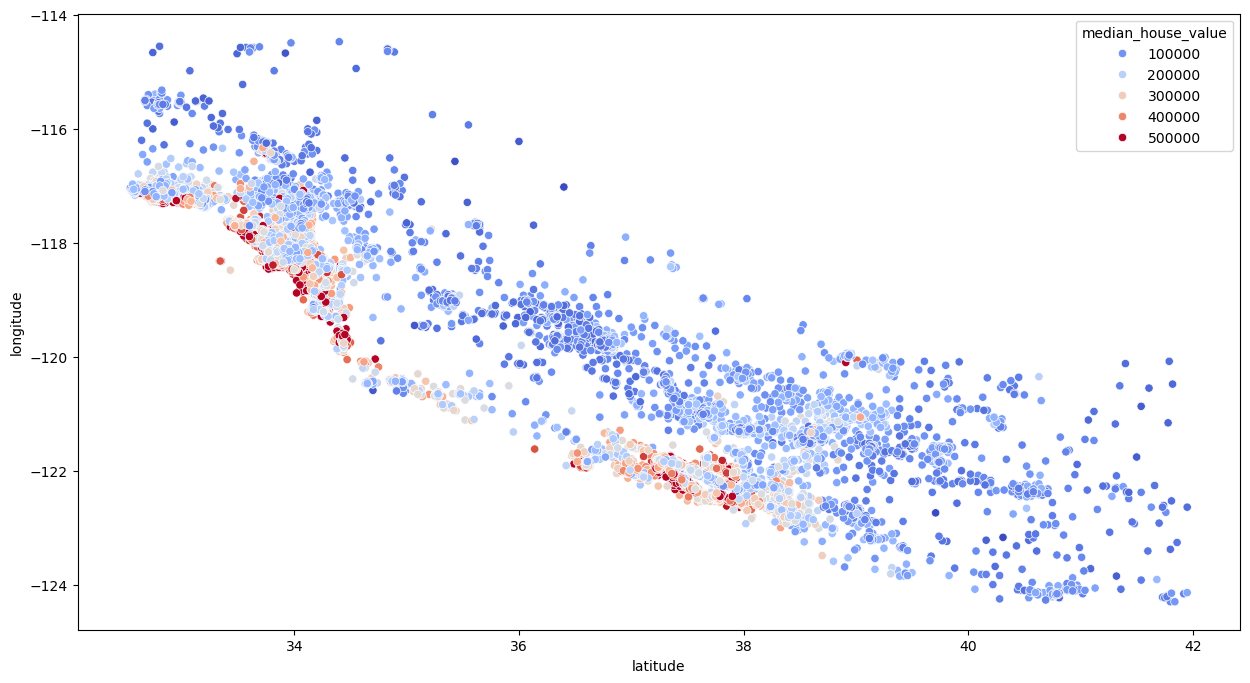

In [65]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

In [66]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

In [67]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

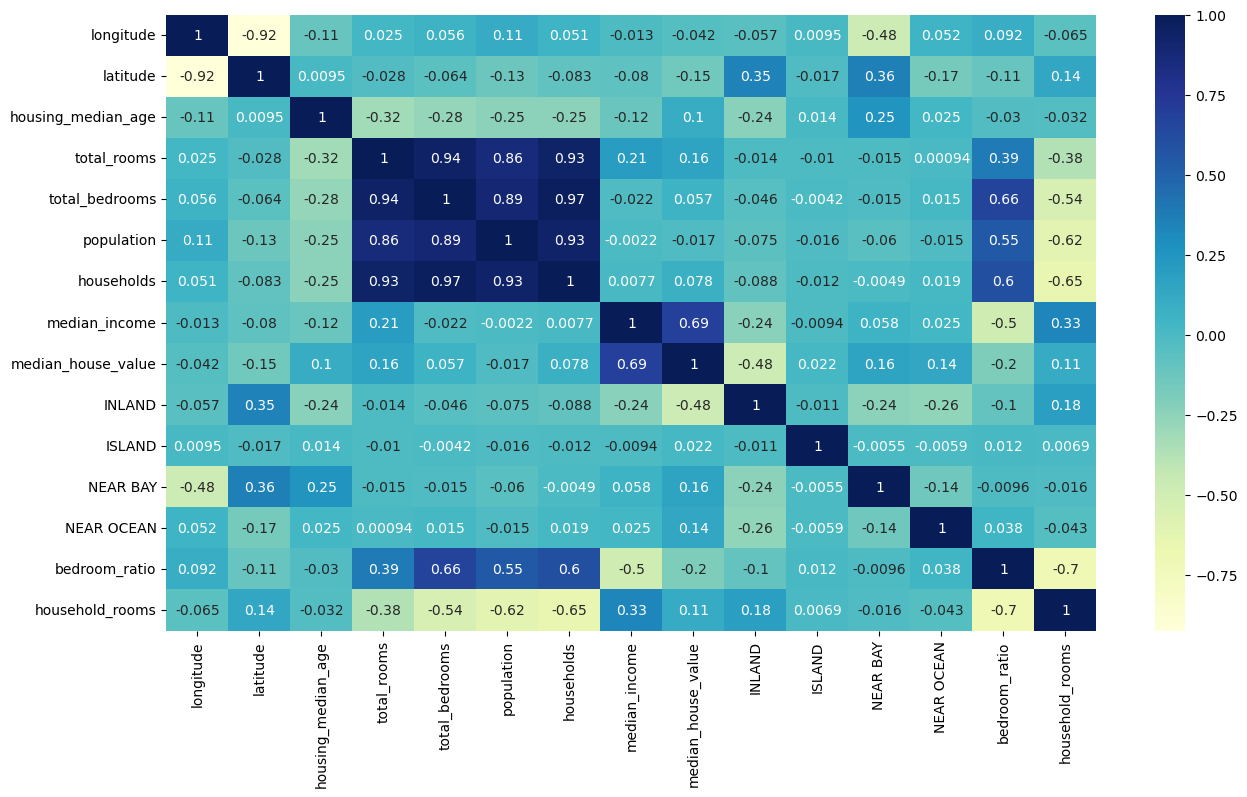

In [68]:
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [89]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']


In [119]:
train_data = x_train.join(y_train)

train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(['ocean_proximity'], axis=1)

train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']


In [126]:
import numpy as np
import pandas as pd

# Apply the same transformations to train data
train_data = x_train.join(y_train)

# Apply log transformation
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

# One-hot encoding (ensuring same columns in train and test)
train_dummies = pd.get_dummies(train_data.ocean_proximity)
test_dummies = pd.get_dummies(x_test.ocean_proximity)

# Align to ensure same columns
train_dummies, test_dummies = train_dummies.align(test_dummies, join="outer", axis=1, fill_value=0)

# Replace ocean_proximity column
train_data = train_data.join(train_dummies).drop(['ocean_proximity'], axis=1)

# Add new feature columns
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

# Repeat similar steps for test data
test_data = x_test.join(y_test)
test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)
test_data = test_data.join(test_dummies).drop(['ocean_proximity'], axis=1)
test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

# Check final shape
print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)


AttributeError: 'DataFrame' object has no attribute 'ocean_proximity'

In [124]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
16596,-121.47,37.58,14.0,7.374629,5.680173,6.788972,5.662960,4.6625,NaN,False,True,False,False,False,0.770232,1.302257
4187,-118.23,34.13,37.0,7.495542,6.056784,6.993015,6.035481,2.9750,NaN,True,False,False,False,False,0.808052,1.241913
18522,-122.05,36.97,16.0,8.120886,6.416732,7.380256,6.322565,4.2542,NaN,False,False,False,False,True,0.790152,1.284429
9657,-120.62,36.99,32.0,7.806289,6.232448,7.204149,6.200509,1.9732,NaN,False,True,False,False,False,0.798388,1.258976
3210,-119.63,36.32,36.0,7.325808,5.662960,6.620073,5.545177,2.2333,61000.0,False,True,False,False,False,0.773015,1.321113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4365,-118.26,34.10,52.0,7.178545,5.575949,6.536692,5.342334,4.0721,NaN,True,False,False,False,False,0.776752,1.343710
6946,-118.08,33.99,38.0,7.428927,5.796058,7.222566,5.828946,3.6196,NaN,True,False,False,False,False,0.780201,1.274489
3850,-118.46,34.18,35.0,7.506592,6.144186,7.198184,6.040255,3.4583,NaN,True,False,False,False,False,0.818505,1.242761
19619,-121.06,37.45,33.0,7.245655,5.703782,6.820016,5.645447,3.4464,NaN,False,True,False,False,False,0.787200,1.283451


In [125]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,NEAR OCEAN,103000.0
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,NEAR OCEAN,382100.0
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,NEAR OCEAN,172600.0
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,NEAR OCEAN,93400.0
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,INLAND,96500.0
...,...,...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700,<1H OCEAN,229200.0
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500,INLAND,97800.0
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344,<1H OCEAN,222100.0
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192,<1H OCEAN,283500.0


In [122]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine X_train & y_train for further preprocessing
train_data = X_train.join(y_train)

# Check shape of train and test data
print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", X_test.shape)


Train Data Shape: (16512, 10)
Test Data Shape: (4128, 9)


In [110]:
from sklearn.linear_model import LinearRegression

# Splitting training data into features (X_train) and target variable (y_train)
X_train = train_data.drop(['median_house_value'], axis=1)
y_train = train_data['median_house_value']

# Initialize and train the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Print model coefficients
print("Model Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)


Model Coefficients: [ -28386.6024582   -27608.82089542    1041.02837353  -78612.24078961
  110031.40820582  -91428.47431051   82259.73423559   40176.65826395
  -29520.43304898  -65848.10212317  163444.11659317  -37644.8325013
  -30430.74891972 -362508.27513303   60001.85508891]
Intercept: -2053296.5759356488


In [111]:
print(X_train.isnull().sum())  # Should print 0 for all columns
print(y_train.isnull().sum())  # Should also be 0


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
<1H OCEAN             0
INLAND                0
ISLAND                0
NEAR BAY              0
NEAR OCEAN            0
bedroom_ratio         0
household_rooms       0
dtype: int64
0


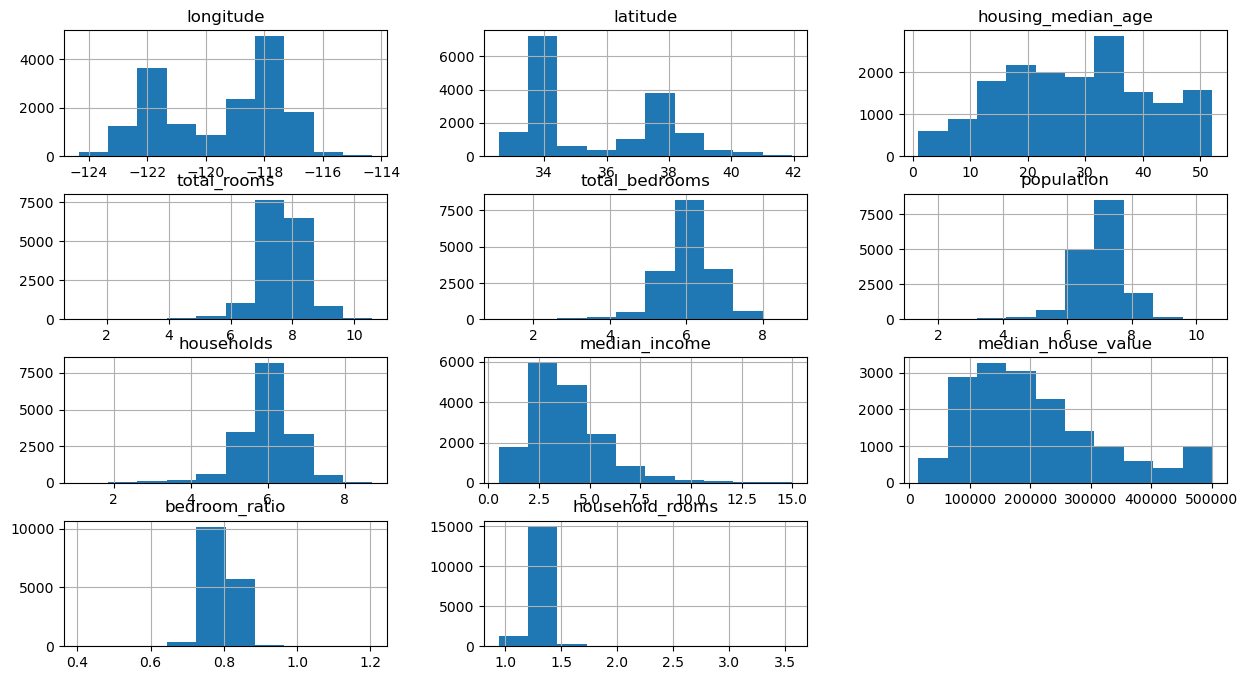

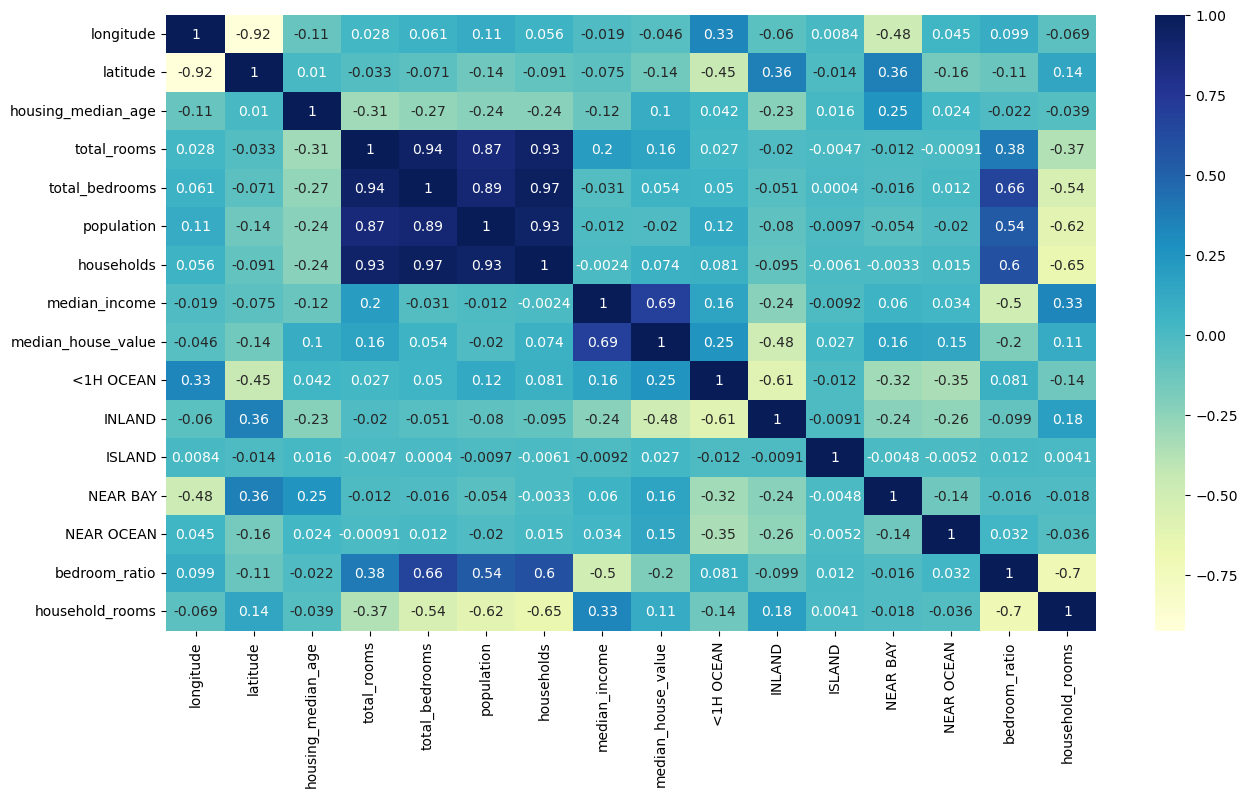

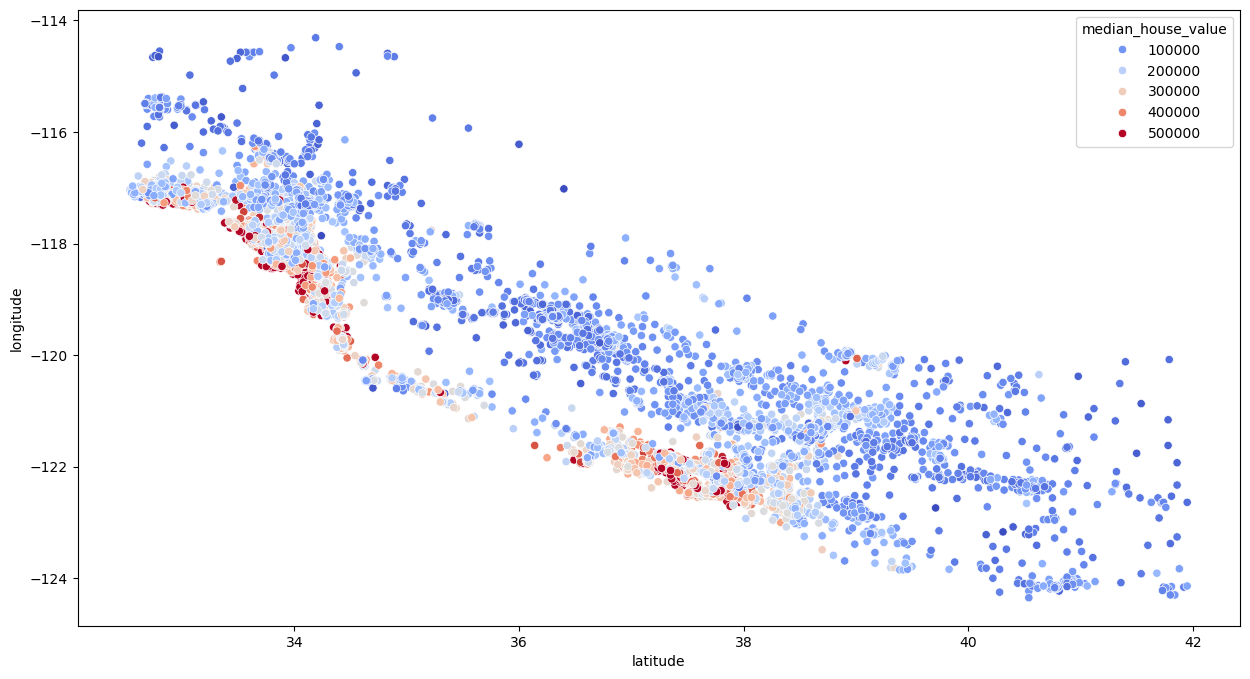

In [112]:
# Histogram of training data features
train_data.hist(figsize=(15, 8))
plt.show()

# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="YlGnBu")
plt.show()

# Scatter plot to analyze location impact on house prices
plt.figure(figsize=(15, 8))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")
plt.show()



In [113]:
from sklearn.linear_model import LinearRegression

# Splitting training data into features (X_train) and target variable (y_train)
X_train = train_data.drop(['median_house_value'], axis=1)
y_train = train_data['median_house_value']

# Initialize and train the Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Print model coefficients
print("Model Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)


Model Coefficients: [ -28386.6024582   -27608.82089542    1041.02837353  -78612.24078961
  110031.40820582  -91428.47431051   82259.73423559   40176.65826395
  -29520.43304898  -65848.10212317  163444.11659317  -37644.8325013
  -30430.74891972 -362508.27513303   60001.85508891]
Intercept: -2053296.5759356488


In [114]:
from sklearn.tree import DecisionTreeRegressor

# Initialize Decision Tree model
dt_reg = DecisionTreeRegressor(random_state=42)

# Train model on training data
dt_reg.fit(X_train, y_train)

# Print model details
print("Decision Tree Model Trained Successfully!")


Decision Tree Model Trained Successfully!


In [117]:
# Predict using Linear Regression
y_pred_lr = reg.predict(X_test)

# Predict using Decision Tree Regressor
y_pred_dt = dt_reg.predict(X_test)

# Display first 5 predictions from both models
print("Linear Regression Predictions:", y_pred_lr[:5])
print("Decision Tree Predictions:", y_pred_dt[:5])

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- ocean_proximity
Feature names seen at fit time, yet now missing:
- <1H OCEAN
- INLAND
- ISLAND
- NEAR BAY
- NEAR OCEAN
- ...
